In [1]:
from __future__ import annotations

from pathlib import Path
import re

import numpy as np
import pandas as pd
import plotly.express as px

In [2]:
RAW_FILES = [
    "data/original/mdot_series_q010_e000.txt",
    "data/original/mdot_series_q025_e000.txt",
    "data/original/mdot_series_q050_e000.txt",
    "data/original/mdot_series_q100_e000.txt",
    "data/original/mdot_series_q100_e050.txt",
    "data/original/mdot_series_q100_e040.txt",
    "data/original/mdot_series_q100_e030.txt",
    "data/original/mdot_series_q100_e020.txt",
    "data/original/mdot_series_q100_e010.txt",
    "data/original/mdot_series_q100_e060.txt",
    "data/original/mdot_series_q100_e070.txt",
]

N_SEGMENTS        = 20                          # segmentos por serie
SEGMENTS_DIR      = Path("data/segments")
SEGMENTS_DIR.mkdir(parents=True, exist_ok=True)
FLOAT_FMT         = "%.18e"

In [3]:
for raw in RAW_FILES:
    raw_path = Path(raw)
    if not raw_path.exists():
        print(f"⚠️  No se encontró {raw_path} – se omite.")
        continue

    df_raw = pd.read_csv(raw_path, delim_whitespace=True, header=None)
    rows_per_seg = len(df_raw) // N_SEGMENTS

    for i in range(N_SEGMENTS):
        start = i * rows_per_seg
        end   = (i + 1) * rows_per_seg if i < N_SEGMENTS - 1 else len(df_raw)
        seg_df = df_raw.iloc[start:end]

        seg_name = raw_path.stem + f"_seg{i+1:02d}" + raw_path.suffix
        seg_df.to_csv(
            SEGMENTS_DIR / seg_name,
            sep=" ",
            header=False,
            index=False,
            float_format=FLOAT_FMT,
        )


In [4]:
PATTERN = "*_seg??.txt"
COLUMN_TIME = "time"
COL_PRIMARY = "acre_rate_primary"
COL_SECOND  = "acre_rate_secondary"
COL_MW      = "acre_rate_mass_weighted"

In [5]:
def _parse_fname(fname: str) -> tuple[float | None, float | None, int | None]:
    """Extrae q, e y número de segmento del nombre de archivo."""
    m = re.search(r"q(\d+)_e(\d+)_seg(\d+)", fname)
    if not m:
        return None, None, None
    q = int(m.group(1)) / 100.0
    e = int(m.group(2)) / 100.0
    s = int(m.group(3))
    return q, e, s


frames: list[pd.DataFrame] = []
for f in sorted(SEGMENTS_DIR.glob(PATTERN)):
    q_val, e_val, seg_id = _parse_fname(f.name)
    if q_val is None:
        print(f"Nombre no coincide: {f.name} – omitido.")
        continue

    df = pd.read_csv(
        f,
        delim_whitespace=True,
        header=None,
        names=[COLUMN_TIME, COL_PRIMARY, COL_SECOND],
    )
    df["q"], df["e"], df["seg"] = q_val, e_val, seg_id

    # peso por masa – (BH₁ másivo, BH₂ menosivo)
    w1 = 1 / (1 + q_val)
    w2 = q_val / (1 + q_val)
    df[COL_MW] = w1 * df[COL_PRIMARY].abs() + w2 * df[COL_SECOND].abs()

    q_tag  = f"{int(round(q_val * 100)):03d}"
    e_tag  = f"{int(round(e_val * 100)):03d}"
    seg_tag = f"{seg_id:02d}"
    df["id"] = f"{q_tag}_{e_tag}_{seg_tag}"

    frames.append(df)

all_data = pd.concat(frames, ignore_index=True)

all_data = all_data[~all_data["seg"].isin({1, 2})]

CSV_CLEAN = Path("data/data_csv/all_data_clean.csv")
CSV_CLEAN.parent.mkdir(parents=True, exist_ok=True)
all_data.to_csv(CSV_CLEAN, index=False)

In [6]:
all_data

,time,acre_rate_primary,acre_rate_secondary,q,e,seg,acre_rate_mass_weighted,id
10000,200.015132,-0.003976,-0.011028,0.1,0.0,3,0.004617,010_000_03
10001,200.030826,-0.003974,-0.011079,0.1,0.0,3,0.004620,010_000_03
10002,200.046532,-0.003971,-0.011159,0.1,0.0,3,0.004625,010_000_03
10003,200.062255,-0.003969,-0.011278,0.1,0.0,3,0.004634,010_000_03
10004,200.093726,-0.003959,-0.011499,0.1,0.0,3,0.004644,010_000_03
...,...,...,...,...,...,...,...,...
1100006,1999.922054,-0.001690,-0.012933,1.0,0.7,20,0.007312,100_070_20
1100007,1999.954098,-0.001862,-0.014619,1.0,0.7,20,0.008241,100_070_20
1100008,1999.969444,-0.001915,-0.015206,1.0,0.7,20,0.008560,100_070_20
1100009,1999.984827,-0.002066,-0.015821,1.0,0.7,20,0.008943,100_070_20


In [7]:
#ruido gaussiano
CSV_NOISY        = Path("data/data_csv/all_data_noisy.csv")
STD_FACTOR       =  2 #  20% de σ
RANDOM_SEED: int | None = None  # «None» → ruido distinto en cada ejecución

rng = np.random.default_rng(RANDOM_SEED) if RANDOM_SEED is not None else np.random.default_rng()
noisy_df = pd.read_csv(CSV_CLEAN)

sigma = noisy_df[COL_MW].std(ddof=1)

# Guarda copia limpia y sobre‑escribe la columna con su versión ruidosa
noisy_df[f"{COL_MW}_clean"] = noisy_df[COL_MW]
noise = rng.normal(0.0, STD_FACTOR * sigma, size=len(noisy_df))
noisy_df[COL_MW] = noisy_df[COL_MW] + noise

#eliminar outliers por número de segmento
#noisy_df = noisy_df[~noisy_df["seg"].isin({1, 2})]

#noisy_df.to_csv(CSV_NOISY, index=False)

In [8]:
noisy_df

,time,acre_rate_primary,acre_rate_secondary,q,e,seg,acre_rate_mass_weighted,id,acre_rate_mass_weighted_clean
0,200.015132,-0.003976,-0.011028,0.1,0.0,3,0.002248,010_000_03,0.004617
1,200.030826,-0.003974,-0.011079,0.1,0.0,3,0.001654,010_000_03,0.004620
2,200.046532,-0.003971,-0.011159,0.1,0.0,3,0.006208,010_000_03,0.004625
3,200.062255,-0.003969,-0.011278,0.1,0.0,3,0.011415,010_000_03,0.004634
4,200.093726,-0.003959,-0.011499,0.1,0.0,3,-0.001921,010_000_03,0.004644
...,...,...,...,...,...,...,...,...,...
990006,1999.922054,-0.001690,-0.012933,1.0,0.7,20,0.009483,100_070_20,0.007312
990007,1999.954098,-0.001862,-0.014619,1.0,0.7,20,0.009626,100_070_20,0.008241
990008,1999.969444,-0.001915,-0.015206,1.0,0.7,20,0.008877,100_070_20,0.008560
990009,1999.984827,-0.002066,-0.015821,1.0,0.7,20,0.017531,100_070_20,0.008943



#ponderar columna tiempo(orbita)
noisy_df['time_days'] = noisy_df['time'] * DAYS_PER_ORBIT

# Cada fila cae en un bucket de longitud OBS_FREQ_DAYS.
# Ej.: si OBS_FREQ_DAYS = 7, todos los días 0-6 → bucket 0, 7-13 → bucket 1
noisy_df['bucket'] = (noisy_df['time_days'] // OBS_FREQ_DAYS).astype(int)



In [9]:
DAYS_PER_ORBIT = 150.0   #factor para ponderar orbita (30, 100,300)
OBS_FREQ_DAYS  = 7.0    #frecuencia observacion(1 = diario, 7 = semanal, 15 = quincenal)
# Claves que definen cada serie
clave = ['id']          # ajusta a tu caso

noisy_df['time_days'] = noisy_df['time'] * DAYS_PER_ORBIT
noisy_df['bucket'] = np.floor((noisy_df['time_days'] + 1e-9) / OBS_FREQ_DAYS).astype(int)

df_unique = (
    noisy_df
        .groupby(clave + ['bucket'], as_index=False)
        .median(numeric_only=True)
        .sort_values(clave + ['time_days'])
        #.drop(columns='bucket')
        .reset_index(drop=True)
)

In [10]:
import pandas as pd
import numpy as np

def filtrar_por_ventana_meses(
    df: pd.DataFrame,
    *,
    col_dias: str = "time_days",
    mes_inicial: int = 1,
    n_meses: int = 6,
    dias_por_anio: int = 365,
    agregar_aux: bool = False
) -> pd.DataFrame:
    
    if col_dias not in df.columns:
        raise ValueError(f"La columna '{col_dias}' no existe en el DataFrame.")

    # Longitud real de cada mes (año no bisiesto)
    dias_mes = np.array([31, 28, 31, 30, 31, 30,
                         31, 31, 30, 31, 30, 31])
    limites = np.concatenate(([0], np.cumsum(dias_mes)))     # 0, 31, 59, …

    # Vector de días (int)
    dias_abs = df[col_dias].astype(int).to_numpy()

    # Año relativo y día dentro del año
    anio_rel = dias_abs // dias_por_anio
    dia_anio = dias_abs % dias_por_anio

    # Mes (1‒12) vía búsqueda binaria en los límites
    mes = np.searchsorted(limites, dia_anio, side="right")

    # Lista de meses permitidos
    meses_ok = [((mes_inicial - 1 + i) % 12) + 1 for i in range(n_meses)]

    # Máscara booleana final
    keep = np.isin(mes, meses_ok)

    out = df.loc[keep].copy().reset_index(drop=True)
    if agregar_aux:
        out["anio_rel"] = anio_rel[keep]
        out["mes"] = mes[keep]

    return out




In [11]:

df_estacion= filtrar_por_ventana_meses(df_unique,
                                       mes_inicial=0,
                                       n_meses=6,
                                       agregar_aux=True)

In [12]:
df_unique

,id,bucket,time,acre_rate_primary,acre_rate_secondary,q,e,seg,acre_rate_mass_weighted,acre_rate_mass_weighted_clean,time_days
0,010_000_03,4286,200.030826,-0.003974,-0.011079,0.1,0.0,3.0,0.002248,0.004620,30004.623835
1,010_000_03,4287,200.077991,-0.003964,-0.011389,0.1,0.0,3.0,0.004747,0.004639,30011.698591
2,010_000_03,4288,200.125280,-0.003948,-0.011704,0.1,0.0,3.0,0.003262,0.004653,30018.792040
3,010_000_03,4289,200.180457,-0.003926,-0.011869,0.1,0.0,3.0,0.004744,0.004648,30027.068530
4,010_000_03,4290,200.219750,-0.003908,-0.011790,0.1,0.0,3.0,0.008902,0.004625,30032.962554
...,...,...,...,...,...,...,...,...,...,...,...
424409,100_070_20,42853,1999.824749,-0.001807,-0.007998,1.0,0.7,20.0,0.004039,0.004903,299973.712281
424410,100_070_20,42854,1999.881559,-0.001708,-0.010768,1.0,0.7,20.0,0.002762,0.006238,299982.233817
424411,100_070_20,42855,1999.913969,-0.001691,-0.012790,1.0,0.7,20.0,0.009289,0.007240,299987.095369
424412,100_070_20,42856,1999.969444,-0.001915,-0.015206,1.0,0.7,20.0,0.009626,0.008560,299995.416598


In [13]:
filtro_id = df_unique[df_unique['id'] == '100_060_20']

In [14]:
filtro_id

,id,bucket,time,acre_rate_primary,acre_rate_secondary,q,e,seg,acre_rate_mass_weighted,acre_rate_mass_weighted_clean,time_days
383687,100_060_20,40714,1900.015667,-0.012356,-0.002961,1.0,0.6,20.0,0.007963,0.007659,285002.350033
383688,100_060_20,40715,1900.060222,-0.014816,-0.004114,1.0,0.6,20.0,0.005965,0.009465,285009.033298
383689,100_060_20,40716,1900.098333,-0.015851,-0.004994,1.0,0.6,20.0,0.011575,0.010423,285014.750000
383690,100_060_20,40717,1900.147674,-0.015984,-0.005585,1.0,0.6,20.0,0.013428,0.010785,285022.151065
383691,100_060_20,40718,1900.191031,-0.015149,-0.005574,1.0,0.6,20.0,0.005810,0.010361,285028.654646
...,...,...,...,...,...,...,...,...,...,...,...
385826,100_060_20,42853,1999.828916,-0.007820,-0.000870,1.0,0.6,20.0,0.006291,0.004345,299974.337349
385827,100_060_20,42854,1999.871940,-0.008031,-0.000844,1.0,0.6,20.0,0.007790,0.004437,299980.791035
385828,100_060_20,42855,1999.921919,-0.008262,-0.000832,1.0,0.6,20.0,0.003153,0.004547,299988.287880
385829,100_060_20,42856,1999.955274,-0.008485,-0.000840,1.0,0.6,20.0,0.006821,0.004663,299993.291131


In [15]:
def plot_segment_by_id_interactive(
    df: pd.DataFrame,
    id: str,
    *,
    save_path: str | None = None,
):
    """Dibuja el segmento correspondiente a `id` en línea interactiva Plotly."""

    subset = df.loc[df["id"] == id].sort_values("time_days")
    if subset.empty:
        raise ValueError(f"ID «{id}» no encontrado en el DataFrame.")

    # ── metadatos para el título ────────────────────────────────────────────
    q_raw, e_raw, seg_raw = subset.loc[:, ["q", "e", "seg"]].iloc[0]

    # q-e pueden venir en 1.00–0.10 o en 100–10; detectamos escala
    is_float = subset["q"].max() <= 10
    q_disp = q_raw if is_float else q_raw / 100.0
    e_disp = e_raw if is_float else e_raw / 100.0

    # asegúrate de que `seg` sea int antes de formatear
    seg_disp = int(round(seg_raw))
    title = f"ID {id}  (q={q_disp:.2f}, e={e_disp:.2f}, seg={seg_disp:02d})"

    # ── gráfico interactivo ────────────────────────────────────────────────
    fig = px.line(
        subset,
        x="time_days",
        y="acre_rate_mass_weighted",
        title=title,
        template="plotly_white",
    )
    fig.update_xaxes(showgrid=True, gridcolor="rgba(0,0,0,0.1)")
    fig.update_yaxes(showgrid=True, gridcolor="rgba(0,0,0,0.1)")
    fig.update_traces(
        hovertemplate="<b>t = %{x:.3f}</b><br>rate = %{y:.3e}<extra></extra>"
    )

    # ── guardado opcional ──────────────────────────────────────────────────
    if save_path:
        out = Path(save_path)
        if out.suffix.lower() == ".html":
            fig.write_html(out)
        else:                               # png, pdf,…
            fig.write_image(out, engine="kaleido", scale=2)
        print(f"✅ Figura guardada en {out}")

    return fig





In [16]:
# Ejemplo de dos segmentos arbitrarios
target_id = "100_050_20"

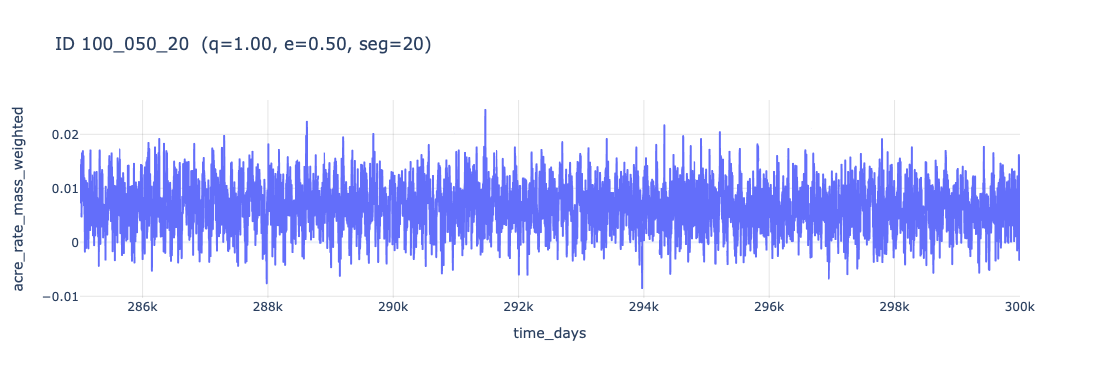

In [17]:
plot_segment_by_id_interactive(noisy_df, id=target_id)

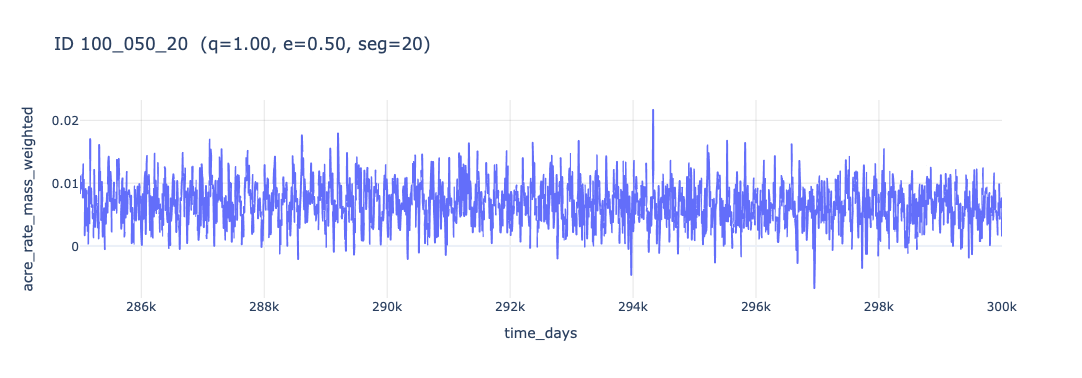

In [18]:
plot_segment_by_id_interactive(df_unique, id=target_id)

In [19]:
def plot_segment_by_id_scatter(df: pd.DataFrame, id: str, *, y: str = "acre_rate_mass_weighted", save_path: str | None = None):
    """Dibuja el segmento correspondiente a `id` como gráfico de dispersión."""
    subset = df.loc[df["id"] == id].sort_values("time_days")
    if subset.empty:
        raise ValueError(f"ID «{id}» no encontrado en el DataFrame.")
    
    # Metadatos para el título
    q_raw, e_raw, seg = subset.loc[:, ["q", "e", "seg"]].iloc[0]
    is_float = subset["q"].max() <= 10
    q_disp = q_raw if is_float else q_raw / 100.0
    e_disp = e_raw if is_float else e_raw / 100.0

    title = f"ID {id}  (q={q_disp:.2f}, e={e_disp:.2f}, seg={int(seg):02d})"
    
    fig = px.scatter(
        subset,
        x="time_days",
        y=y,
        title=title,
        labels={"time_days": "time_days", y: y},
        template="plotly_white"
    )

    fig.update_traces(marker=dict(size=4))

    if save_path:
        fig.write_html(save_path)
    fig.show()

all_data['time_days'] = all_data['time'] * DAYS_PER_ORBIT
all_data['bucket'] = np.floor((all_data['time_days'] + 1e-9) / OBS_FREQ_DAYS).astype(int)


In [20]:
import pandas as pd
from typing import List, Optional, Tuple, Union
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def plot_id_across_dfs(
    dfs: List[pd.DataFrame],
    id: str,
    *,
    y: str = "acre_rate_mass_weighted",
    x_range: Optional[Tuple[Union[int, float], Union[int, float]]] = None,
    save_path: Optional[str] = None,
    height_per_plot: int = 300
):
    """
    Dibuja el mismo segmento `id` en cada DataFrame de `dfs`,
    apilando los scatter plots verticalmente.

    Parámetros:
    -----------
    dfs : List[pd.DataFrame]
        Lista de DataFrames con columnas 'id', 'time_days', 'q', 'e', 'seg'.
    id : str
        Identificador del segmento a graficar en todos los dfs.
    y : str, opcional
        Columna para el eje y.
    x_range : tuple (xmin, xmax), opcional
        Límites del eje x.
    save_path : str, opcional
        Ruta para guardar HTML.
    height_per_plot : int
        Altura de cada subplot en píxeles.
    """
    n = len(dfs)
    # Generamos un título para cada subplot (puedes personalizar nombres de dfs)
    titles = [
        "Simulaciones Originales",
        "Ruido Gaussiano",
        "Frecuencia de observacion",
        "Estacionalidad"
    ]


    # Creamos subplots
    fig = make_subplots(
        rows=n, cols=1,
        shared_xaxes=True,
        vertical_spacing=0.05,
        subplot_titles=titles
    )

    # Añadimos cada serie
    for row, df in enumerate(dfs, start=1):
        subset = df.loc[df["id"] == id].sort_values("time_days")
        fig.add_trace(
            go.Scatter(
                x=subset["time_days"],
                y=subset[y],
                mode="markers",
                marker=dict(size=4),
                showlegend=False
            ),
            row=row, col=1
        )
        fig.update_yaxes(title_text=y, row=row, col=1)

    # Acotar eje x si se pide
    if x_range is not None:
        fig.update_xaxes(range=list(x_range))

    fig.update_layout(
        height=height_per_plot * n,
        template="plotly_white",
        title_text=f"Evolución de datos preparados para curva {id}",
        title_x=0.5
    )

    if save_path:
        fig.write_html(save_path)


    fig.show()

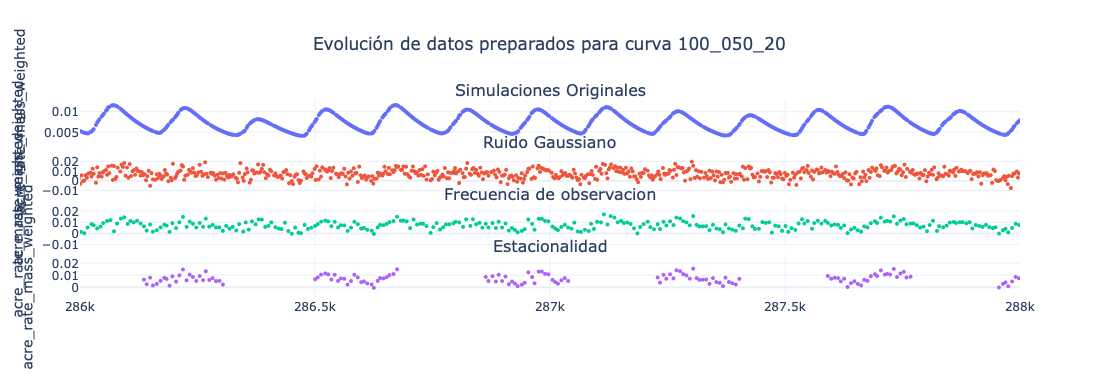

In [21]:

dfs = [all_data, noisy_df, df_unique, df_estacion]


plot_id_across_dfs(
    dfs,
    "100_050_20",
    x_range=(286000, 288000)
)


In [24]:
#df_unique.to_csv(CSV_NOISY, index=False)
df_estacion.to_csv(CSV_NOISY, index=False)
